In [1]:
# solver for Yukawa potential
# central field potential - use radial schrodinger eqn

In [4]:
# ========================
# Import Packages/Modules
# ========================
import matplotlib.pyplot as plt  # from hydrogen.py
import numpy as np  # from hydrogen.py
from jwanglibs import rootfinder as rtf  # from hydrogen.py
import matplotlib.cm as cm  # for colormap plots
from scipy.integrate import trapezoid  # wf normalization
from scipy.constants import m_p, m_n

In [5]:
# =================================
# Conversions to MeV/Natural Units
# =================================
# Proton Mass
mP = m_p  # kg
mP = mP*1e30  # change order scale
mP = mP/1.783  # MeV/c^2, but c = 1 in natural units
print('mP = %.5f MeV' %mP)  # MeV

# Neutron Mass
mN = m_n  # kg
mN = mN*1e30  # change order scale
mN = mN/1.783  # MeV/c^2, but c = 1 in natural units
print('mN = %.5f MeV' %mN)  # MeV

mP = 938.09418 MeV
mN = 939.38727 MeV


In [6]:
#For now, we will be using 1.0 for our constants for easy calculation and visualization.

In [ ]:
# ========================
# Define Yukawa Potential
# ========================
def V(r):
    '''
    Yukawa piecewise potential:
        Spherical well inside interaction range a (depth varied by V0)
        Exponential decay outside well (interaction strength varied by lamda)

    Another method:
        if r <=a:
            return -V0
        else:
            return np.exp(-lamda*r)/r
        Then -> V_vec = np.vectorize(V) to allow for vectorized plotting
    '''
    return np.where(r <= a, -V0, np.exp(-lamda*r)/r)

In [8]:
# =============================
# Define Centrifugal Potential
# =============================
def centrifugal(r):
    '''
    Centrifugal potential:
    L = orbital angular momentum quantum number
    Disappears for 1s states (L=0)
    '''
    return hbar**2*L*(L+1)/(2*m*r**2)

In [9]:
# ===========================
# Define Effective Potential
# ===========================
def V_eff(r):   # effective potential
    '''
    from hydrogen.py
    return L*(L+1)/(2*m*r**2) - 1/(4*pi*)/r  # centrifugal + coulomb
    '''
    return centrifugal(r) + V(r)  # centrifugal + yukawa

In [10]:
# ========================
# Define Numerov Schr Eqn
# ========================
def f(r):  # Sch eqn in Numerov form
    return 2*m*(E-V_eff(r))/hbar**2  # rearrange radial Sch eqn

In [11]:
# ====================
# Define Numerov func
# ====================
def numerov(f, u, n, x, h):  # Numerov function
    '''
    Numerov integrator for $u''+f(x)u=0$
    '''
    nodes, c = 0, h**2/12.  # given $[u_0,u_1]$, return $[u_0,u_1,...,u_{n+1}]$
    f0, f1 = f(x), f(x+h)
    for i in range(n):
        x += h
        f2 = f(x+h)  # Numerov method below
        u.append((2*(1-5*c*f1)*u[i+1] - (1+c*f0)*u[i])/(1+c*f2))  # Numerov update
        f0, f1 = f1, f2
        if u[-1]*u[-2] < 0.0:
            nodes += 1
    return u, nodes  # return u, nodes

In [12]:
# ==================
# Define shoot func
# ==================
def shoot(En):  # Shooting function
    global E  # E needed in f(r)
    E, c, xm = En, (h**2)/6., xL + M*h
    wfup, nup = numerov(f, [0,.1], M, xL, h)  # outward integration from left
    wfdn, ndn = numerov(f, [0,.1], N-M, xR, -h)  # inward integration from right
    dup = ((1+c*f(xm+h))*wfup[-1] - (1+c*f(xm-h))*wfup[-3])/(h+h)
    ddn = ((1+c*f(xm+h))*wfdn[-3] - (1+c*f(xm-h))*wfdn[-1])/(h+h)
    return dup*wfdn[-2] - wfup[-2]*ddn

In [98]:
# ===================
# Initial Conditions
# ===================
xL, xR, N = 10e-6, 12., 3000  # limits, interval
hbar, V0 = 1.0, 20.0  # constants
m = 1.0
#m = mP  # mass of proton
a = 2.0  # radius of potential well [L]^1 (fm)
lamda = 0.2  # yukawa interaction range [L]^-1 (fm^-1)
h = (xR-xL)/N  # step size
Lmax, EL = 6, []  # define max L, blank L array
M = int(a*N/xR)  # M = matching point

In [99]:
# ================================================
# Calculate energy for n, l, and associated nodes
# ================================================
Estart, dE = -V0-0.1, 0.001  # scan from well bottom -V0
list_psix = [[] for _ in range(Lmax)]  # store wfs for each L and n
#list_n = []

for L in range(Lmax):  # pure bound states (E < 0)
    n, E1, Ea = L+1, Estart, []
    while (E1 < -4*dE):  # sweep E range for each L for pure bound states (E < 0)
    #while (E1 < np.exp(-lamda*a)/a + hbar**2*L*(L+1)/(2*m*a**2)):  # sweep E range for each L until upper well bound
        E1 += dE
        if (shoot(E1)*shoot(E1 + dE) > 0):
            continue
        E = rtf.bisect(shoot, E1, E1 + dE, 1.e-8)
        Ea.append(E)  # append E value to energy array Ea
        wfup, nup = numerov(f, [0,.1], M-1, xL, h)  # calc wf
        wfdn, ndn = numerov(f, [0,.1], N-M-1, xR, -h)
        psix = np.concatenate((wfup[:-1], wfdn[::-1]))
        psix[M:] *= wfup[-1]/wfdn[-1]  # match
        list_psix[L].append(psix)
        #list_n.append(n)
        
        print ('nodes = %i, n = %i,l = %i, E = %.8e' %(nup+ndn, n, L, E))
        n += 1
    EL.append(Ea)

nodes = 0, n = 1,l = 0, E = -1.89386448e+01
nodes = 1, n = 2,l = 0, E = -1.57727501e+01
nodes = 2, n = 3,l = 0, E = -1.05734966e+01
nodes = 3, n = 4,l = 0, E = -3.58427915e+00
nodes = 0, n = 2,l = 1, E = -1.78312325e+01
nodes = 1, n = 3,l = 1, E = -1.36288201e+01
nodes = 2, n = 4,l = 1, E = -7.46643540e+00
nodes = 3, n = 5,l = 1, E = -1.49784272e-02
nodes = 0, n = 3,l = 2, E = -1.64365878e+01
nodes = 1, n = 4,l = 2, E = -1.12000982e+01
nodes = 2, n = 5,l = 2, E = -4.13863576e+00
nodes = 0, n = 4,l = 3, E = -1.47691870e+01
nodes = 1, n = 5,l = 3, E = -8.50389063e+00
nodes = 2, n = 6,l = 3, E = -6.90485817e-01
nodes = 0, n = 5,l = 4, E = -1.28393634e+01
nodes = 1, n = 6,l = 4, E = -5.56004899e+00
nodes = 0, n = 6,l = 5, E = -1.06554516e+01
nodes = 1, n = 7,l = 5, E = -2.39612954e+00


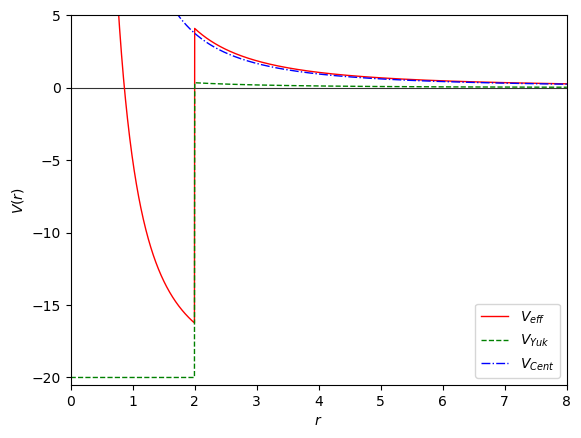

In [140]:
# plot potential
r = np.linspace(xL, xR, N)  # r range

plt.figure()
plt.axhline(0, color='k', ls='-', lw=0.8, alpha=0.8)  # dashed x-axis
plt.plot(r, V_eff(r), 'r-', lw=1.0, label='$V_{eff}$')
plt.plot(r, V(r), 'g--', lw=1.0, label='$V_{Yuk}$')
plt.plot(r, centrifugal(r), 'b-.', lw=1.0, label='$V_{Cent}$')
plt.xlim(0, 8)
plt.ylim(-V0-0.5, 5)
plt.xlabel('$r$')
plt.ylabel('$V(r)$')
plt.legend()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_33863/1265869024.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_33863/1265869024.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')


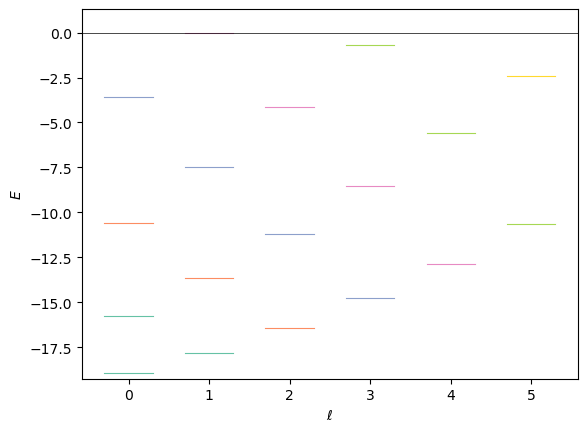

In [122]:
# =========
# Plotting
# =========
# Some code for plotting added with help of Claude

# Create a colormap for different n-values
max_n = max(len(EL[L]) for L in range(Lmax))  # Find max number of n-values
'''
colors = cm.Setet(np.linspace(0, 1, Lmax + max_n))  # extend colormap for all possible n

plt.figure()  # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, color=colors[L+i], lw=1.3)  # Add label for legend
    plt.axhline(0, color='r', ls='--', lw=0.5)
    plt.xlabel('$\ell$'), plt.ylabel('$E$')
    plt.ylim(EL[0][0]-0.3, 0.3), plt.xticks(range(Lmax))
'''
colors = cm.Set2(np.linspace(0, 1, Lmax + max_n))  # extend colormap for all possible n
#colors = cm.hsv(np.linspace(0, 1, Lmax + max_n))  # extend colormap for all possible n

#legend = set()  # track which n values have been added to legend

plt.figure()  # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        list_n = L+i+1  # quantum number n
        label = f'$n$ = {list_n}' if list_n not in legend else None
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, color=colors[L+i], lw=0.8, label=label, alpha=1.0)
        #legend.add(list_n)  # append n value to prevent duplicate legend entries

plt.axhline(0, color='k', ls='-', lw=0.5, alpha=1.0)
plt.xlabel('$\ell$'), plt.ylabel('$E$')
plt.ylim(EL[0][0]-.3, 1.3), plt.xticks(range(Lmax))
#plt.ylim(EL[0][0]-.3, EL[-1][-1]+.3), plt.xticks(range(Lmax))
#plt.legend(title='$n$ values', loc='upper center')
plt.show()

[0.00000000e+00 5.60795027e-03 1.12157101e-02 ... 5.40337597e-29
 3.60043161e-29 1.79967023e-29]


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_33863/4268014236.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')


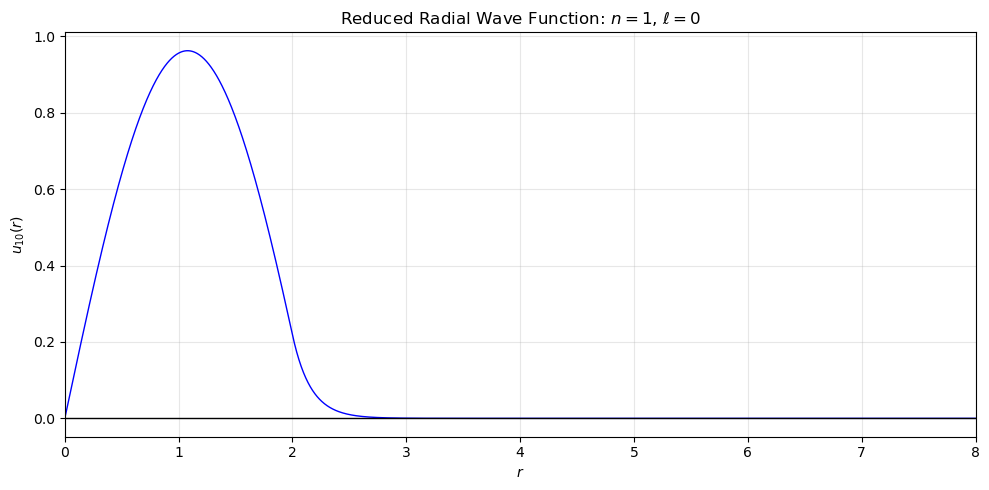

[ 0.00000000e+00  1.11525907e-02  2.23036728e-02 ... -2.10812970e-26
 -1.40482864e-26 -7.02237010e-27]


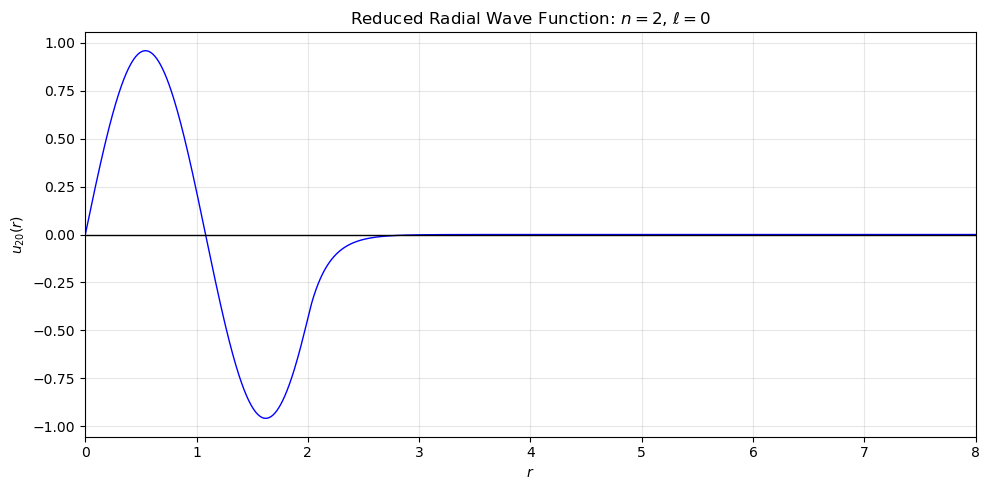

[0.00000000e+00 1.65096744e-02 3.30143687e-02 ... 6.58765732e-22
 4.39053271e-22 2.19489476e-22]


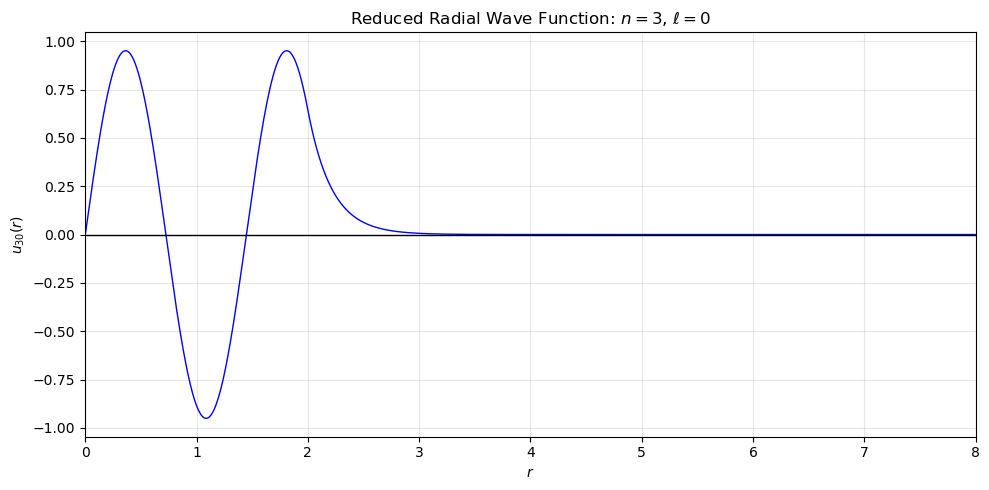

[ 0.00000000e+00  2.11029185e-02  4.21947520e-02 ... -9.91974041e-14
 -6.61252691e-14 -3.30607345e-14]


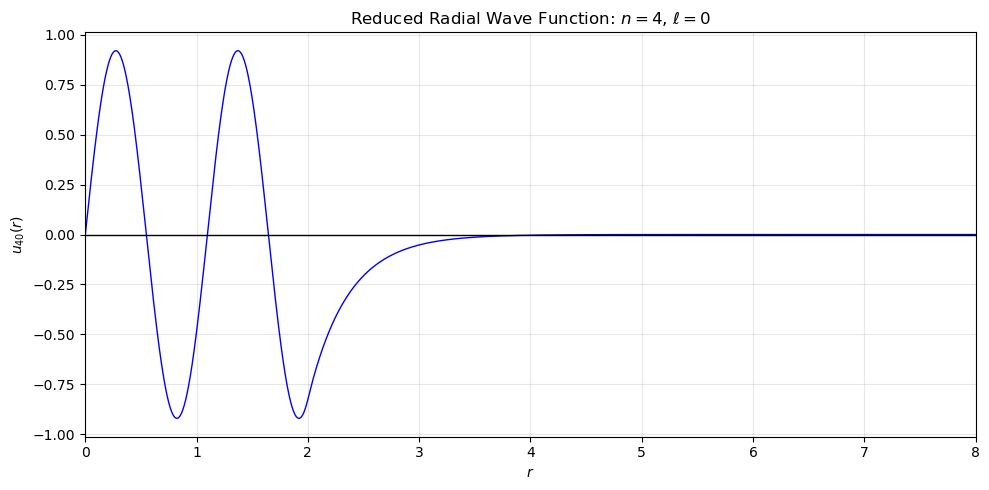

[0.00000000e+00 2.40803686e-05 9.19129925e-05 ... 4.34161386e-28
 2.89303250e-28 1.44610332e-28]


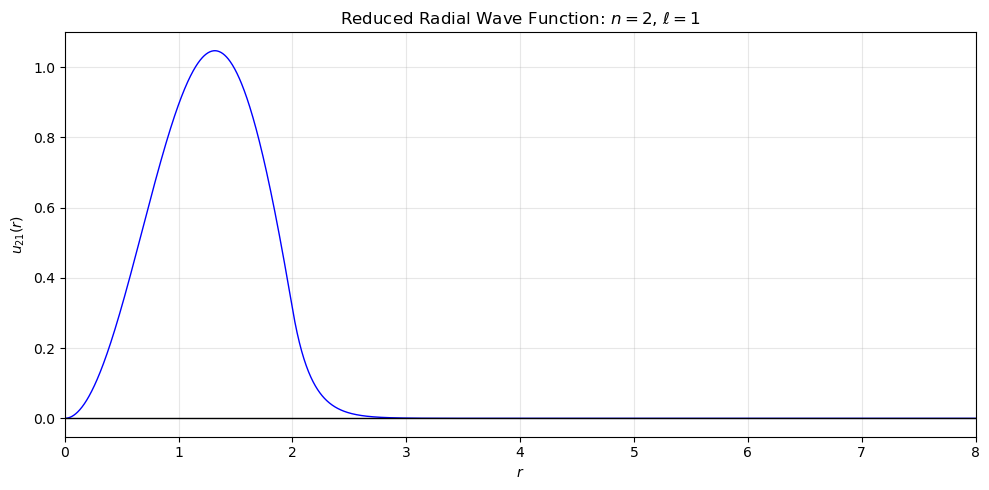

[ 0.00000000e+00  6.92579836e-05  2.64341431e-04 ... -1.15476392e-24
 -7.69562633e-25 -3.84697337e-25]


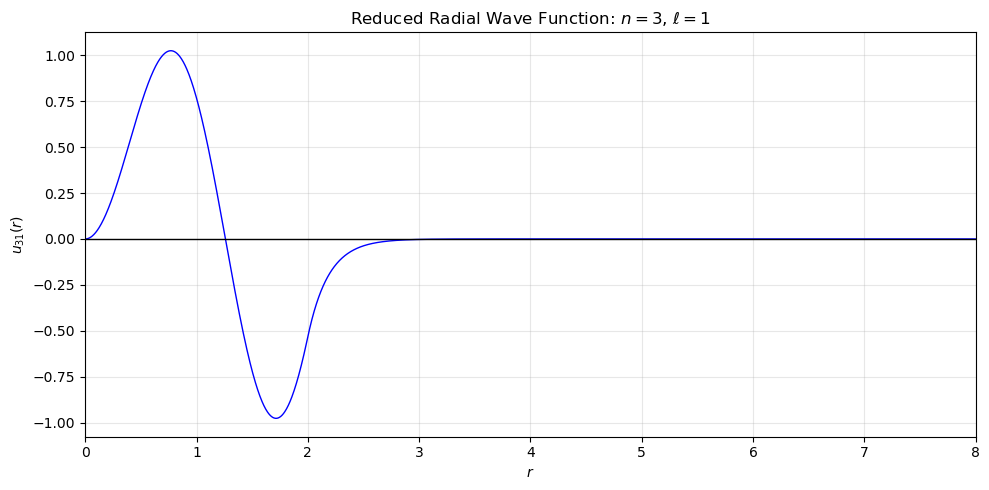

[0.00000000e+00 1.33769246e-04 5.10534054e-04 ... 8.65553430e-19
 5.76920530e-19 2.88425741e-19]


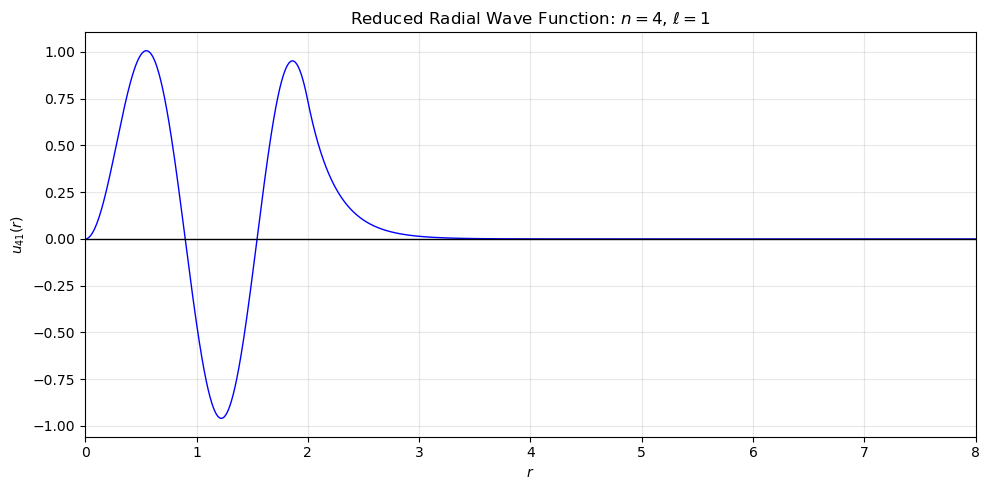

[ 0.00000000e+00  1.73907895e-04  6.63674514e-04 ... -9.57432338e-05
 -6.38287723e-05 -3.19143711e-05]


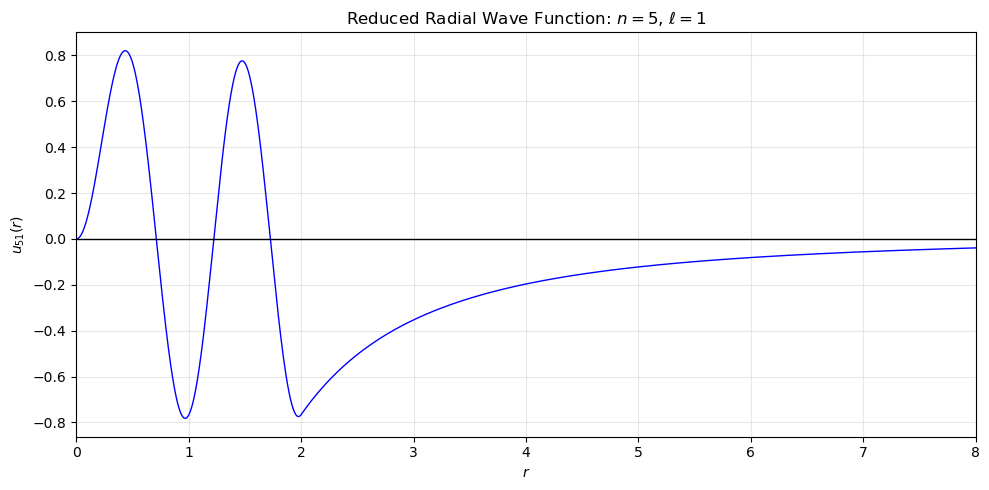

[0.00000000e+00 8.23037470e-08 6.55837378e-07 ... 5.01073482e-27
 3.33902384e-27 1.66907220e-27]


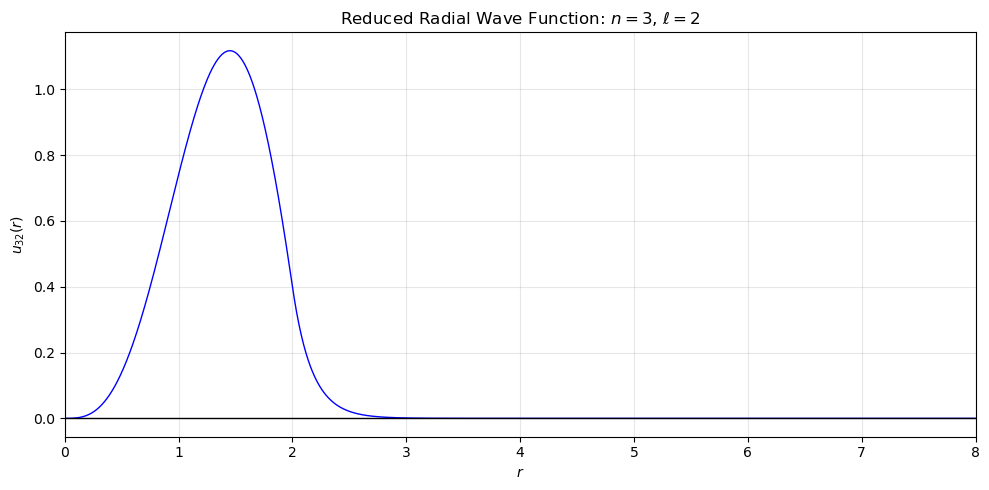

[ 0.00000000e+00  3.08005437e-07  2.45425292e-06 ... -1.34529257e-22
 -8.96593251e-23 -4.48216098e-23]


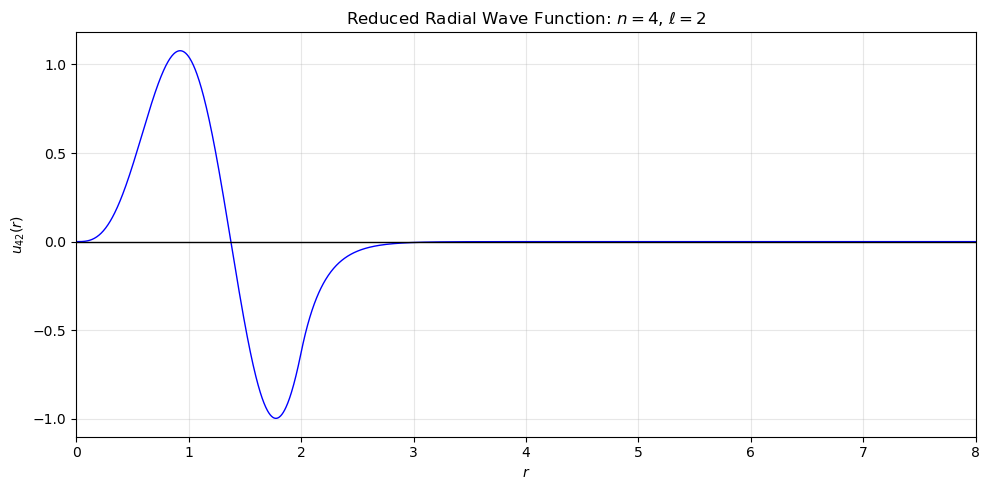

[0.00000000e+00 7.20319297e-07 5.73937915e-06 ... 9.91845474e-15
 6.61156848e-15 3.30556384e-15]


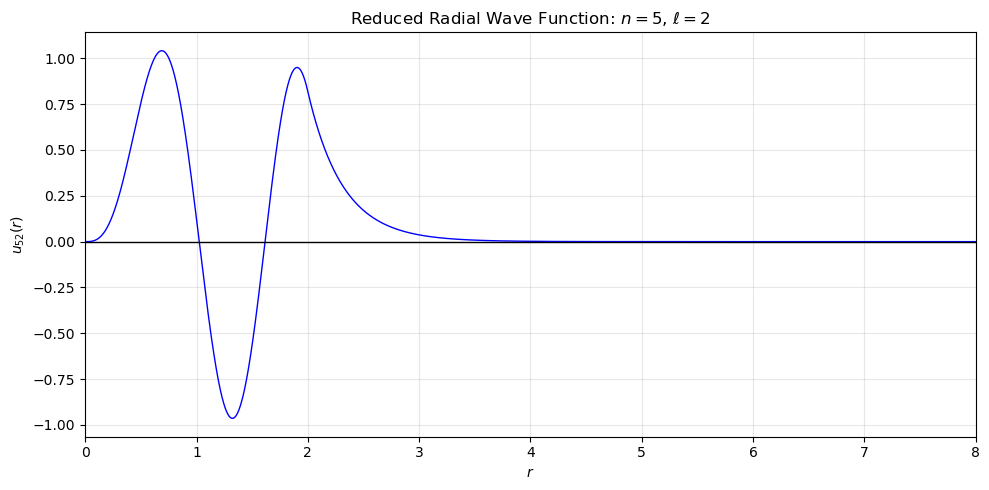

[0.00000000e+00 2.76223433e-10 4.39743802e-09 ... 9.03910160e-26
 6.02368744e-26 3.01112977e-26]


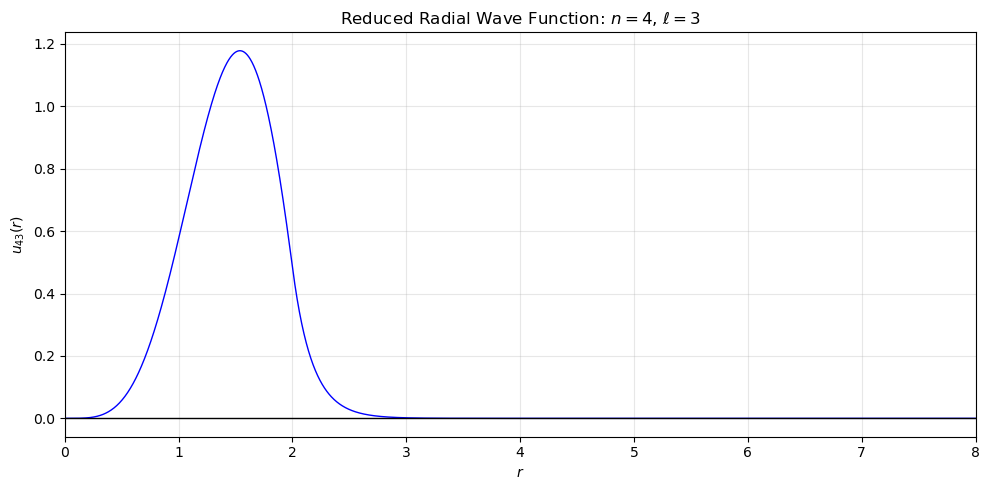

[ 0.00000000e+00  1.26941697e-09  2.02082064e-08 ... -4.24157971e-20
 -2.82707500e-20 -1.41334408e-20]


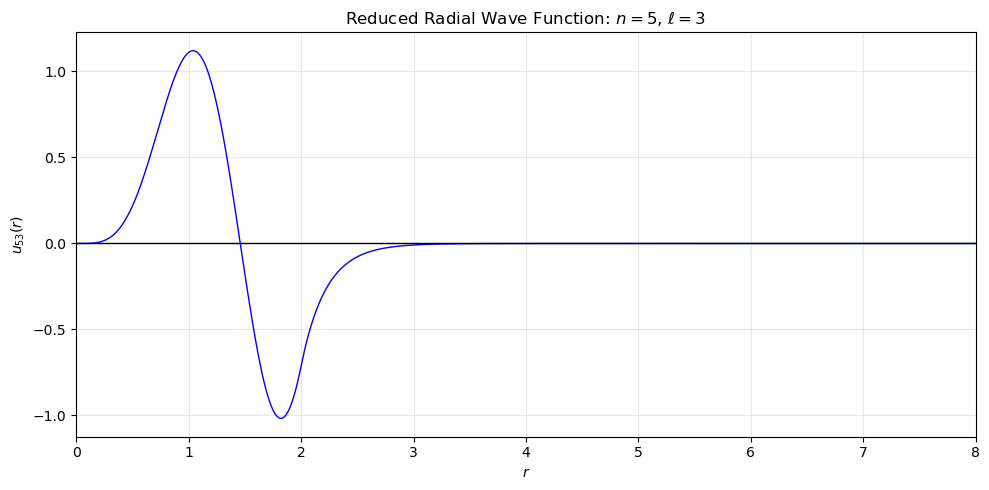

[0.00000000e+00 3.32012152e-09 5.28515613e-08 ... 2.72422012e-08
 1.81611092e-08 9.08044712e-09]


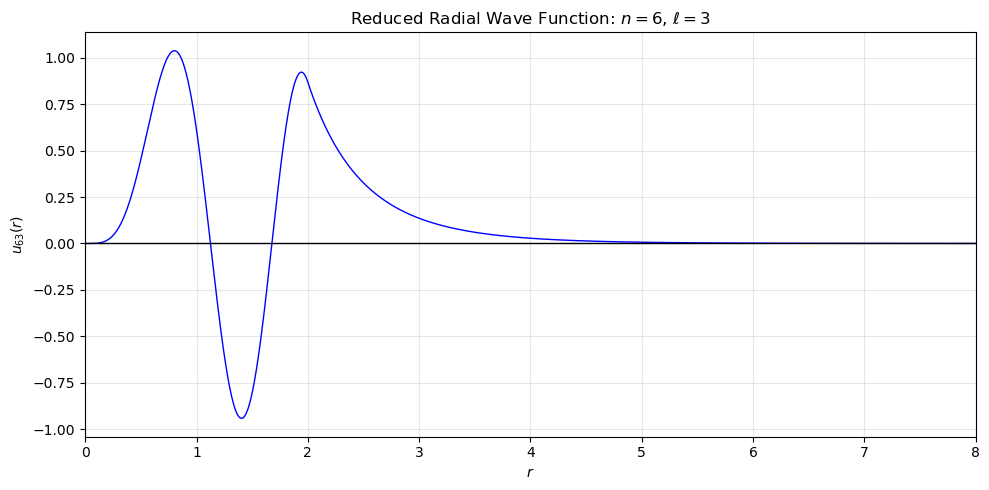

[0.00000000e+00 8.86662086e-13 2.81955259e-11 ... 2.76948172e-24
 1.84568542e-24 9.22652027e-25]


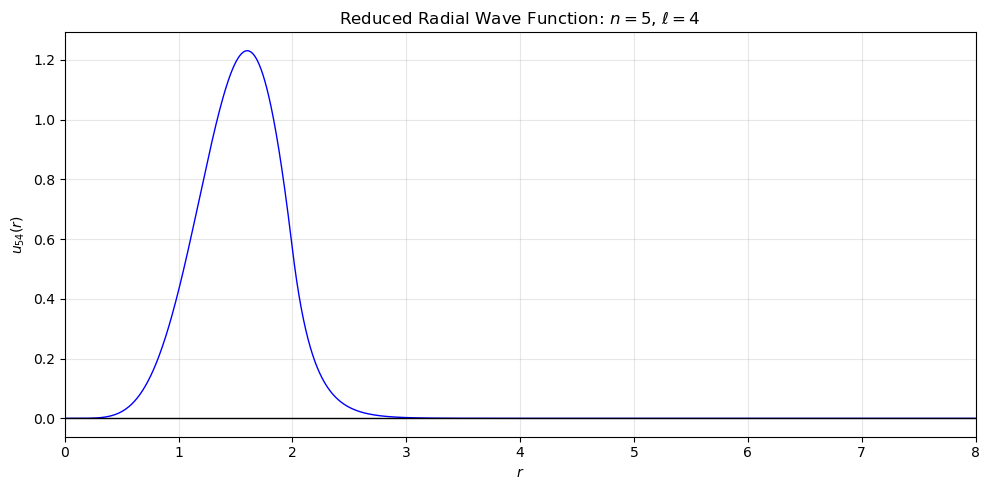

[ 0.00000000e+00  4.80616099e-12  1.52827466e-10 ... -5.72736627e-17
 -3.81767030e-17 -1.90866300e-17]


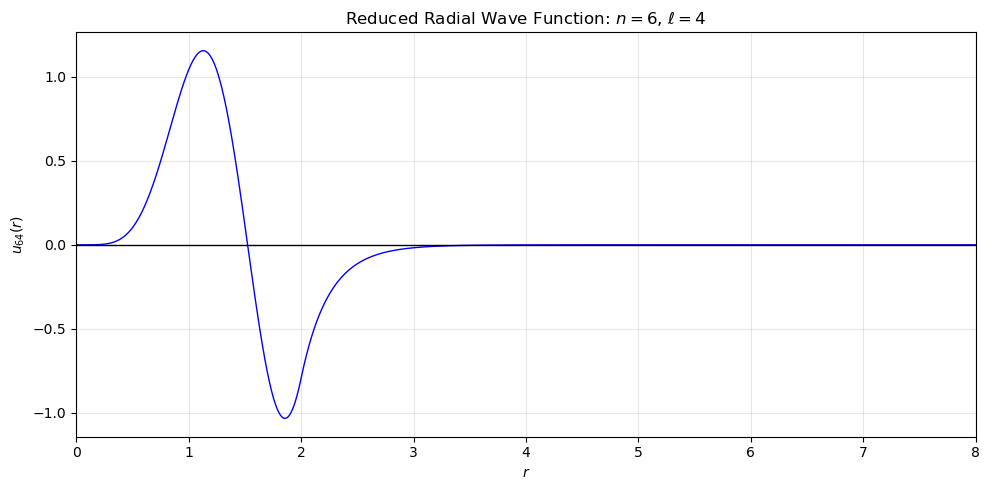

[0.00000000e+00 2.43581885e-15 1.73833929e-13 ... 1.61606727e-22
 1.07706892e-22 5.38441698e-23]


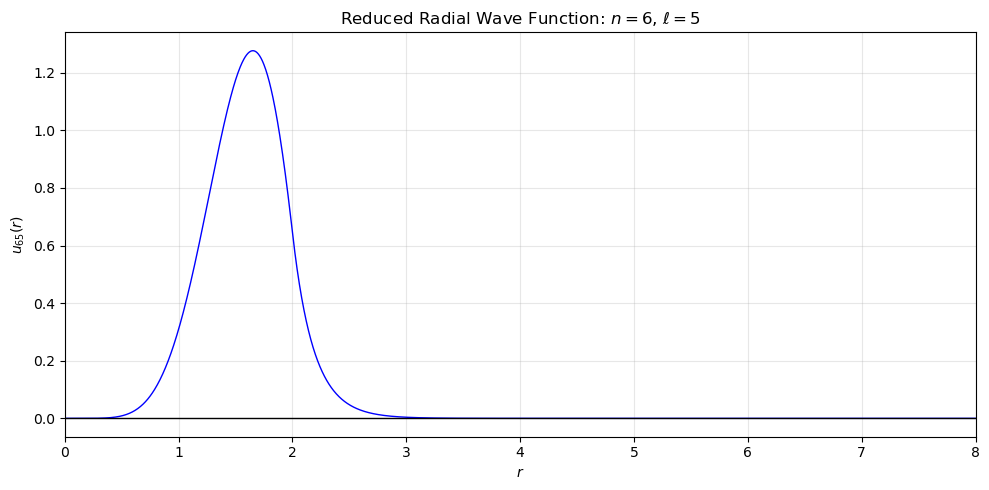

[ 0.00000000e+00  1.50337684e-14  1.07282394e-12 ... -1.10290309e-12
 -7.35219553e-13 -3.67595026e-13]


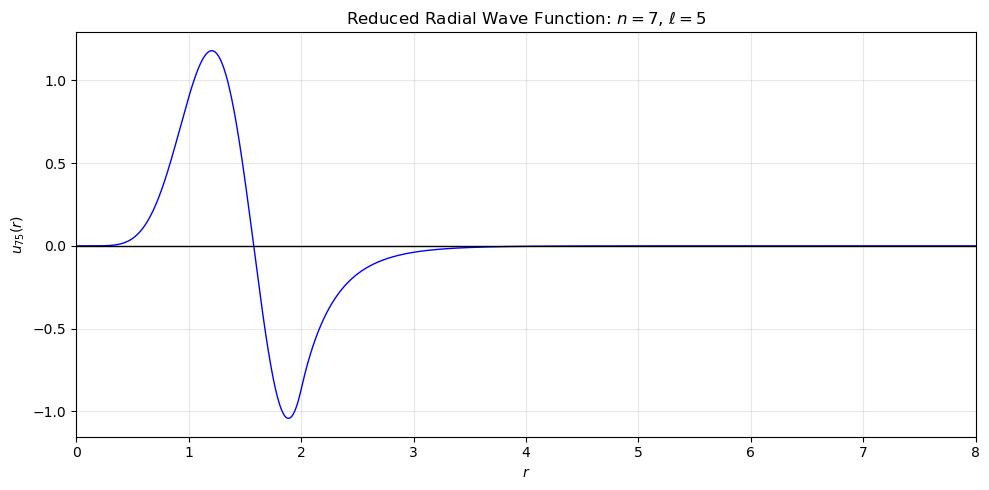

In [134]:
# plot normalized reduced radial wave functions for all L and n values
for L in range(Lmax):
    for i, psi in enumerate(list_psix[L]):
        psi_truncated = psi[:len(r)]
        norm = np.sqrt(trapezoid(abs(psi_truncated)**2, r)) # normalize
        psi_normalized = psi_truncated / norm
        print(psi_normalized)

        prob_density = abs(psi_normalized)**2

        plt.figure(figsize=(10, 5))
        plt.plot(r, psi_normalized, lw=1.0, color='b')
        #plt.plot(r, prob_density, lw=1.5, color='orange', label='Probability Density')  # Add probability density plot
        #plt.plot(r, V_eff(r), 'r--', alpha=0.5)
        plt.axhline(0, color='k', ls='-', lw=1.0, alpha=1.0)
        plt.xlabel('$r$')
        plt.ylabel(f'$u_{{{L+i+1}{L}}}(r)$')
        plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 8)  # Focus on region near potential well
        #plt.ylim(-22, 5)
        plt.tight_layout()
        plt.show()